In [10]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import collections
import os
import shutil
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [12]:
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

In [13]:
# Χρησιμοποιούμε το MobileNetV2 χωρίς το τελευταίο classifier layer
# Το MobileNetV2 παράγει 1280-dim features (αντί 512 του ResNet18 και 2048 του ResNet50)
feature_extractor = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
feature_extractor.classifier = nn.Identity()  # Αφαιρούμε το classifier (fc layers)
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [14]:
# Dataset με ΟΛΕΣ τις εικόνες μαζί
all_dataset = torchvision.datasets.ImageFolder(root="C:/Users/panag/Desktop/Thesis/Datasets/AllImages/All", transform=transform_test)
all_loader = torch.utils.data.DataLoader(all_dataset, batch_size=32, shuffle=False)

In [15]:
# Εξάγουμε τα features
all_features = []
all_paths = []

with torch.no_grad():
    for inputs, _ in all_loader:
        inputs = inputs.to(device)
        features = feature_extractor(inputs)
        all_features.extend(features.cpu().numpy())

all_features = np.array(all_features)
print(f"Features shape: {all_features.shape}")
# Αναμενόμενο: (3059, 1280)

Features shape: (3059, 1280)


In [16]:
# ΒΗΜΑ 2: K-means Clustering

# StandardScaler
scaler = StandardScaler()
features_scaled = scaler.fit_transform(all_features)

# L2 Normalization
features_scaled = normalize(features_scaled, norm='l2')

# PCA με 95% variance αυτόματα
pca = PCA(n_components=0.95)
features_pca = pca.fit_transform(features_scaled)
print(f"Components που επιλέχθηκαν: {pca.n_components_}")

# K-means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=50, max_iter=500)
clusters = kmeans.fit_predict(features_pca)
print(f"Cluster distribution: {collections.Counter(clusters)}")

Components που επιλέχθηκαν: 457
Cluster distribution: Counter({np.int32(0): 1210, np.int32(2): 1058, np.int32(1): 791})


In [17]:
# Αντιστοίχιση Clusters → Κατηγορίες
# ΠΡΟΣΟΧΗ: Ελέγξε τα clusters οπτικά πριν αντιστοιχίσεις!
# Τα cluster IDs (0,1,2) μπορεί να αντιστοιχούν σε διαφορετική σειρά από το ResNet50

cluster_names = {
    0: "NoWaste",
    1: "Low",
    2: "High"}

# Αποθήκευση εικόνων στους φακέλους
output_dir = "C:/Users/panag/Desktop/Thesis/Datasets/With_L2/KMeans_Dataset_with_MobileNetV2"

# Δημιουργία φακέλων
for name in cluster_names.values():
    os.makedirs(f"{output_dir}/train/{name}", exist_ok=True)
    os.makedirs(f"{output_dir}/test/{name}", exist_ok=True)

# Αντιγραφή εικόνων στους σωστούς φακέλους
image_paths = [all_dataset.imgs[i][0] for i in range(len(all_dataset))]

for i, (path, cluster) in enumerate(zip(image_paths, clusters)):
    category = cluster_names[cluster]
    split = "train" if i % 5 != 0 else "test"
    filename = os.path.basename(path)
    shutil.copy(path, f"{output_dir}/{split}/{category}/{filename}")

print("Completed")
print(f"\nΚατανομή dataset:")
for cluster_id, name in cluster_names.items():
    count = list(clusters).count(cluster_id)
    print(f"  {name}: {count} εικόνες")

Completed

Κατανομή dataset:
  NoWaste: 1210 εικόνες
  Low: 791 εικόνες
  High: 1058 εικόνες


Components για 95% variance: 457


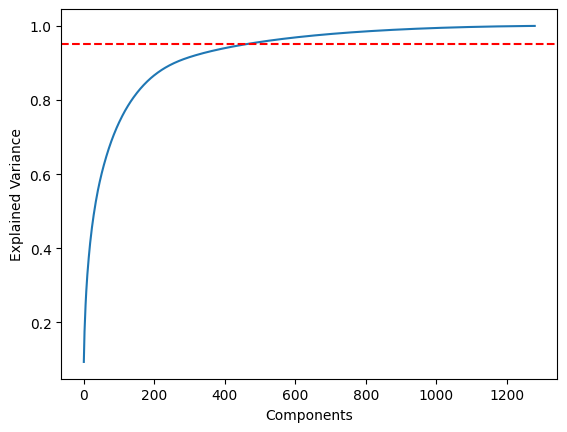

In [18]:
pca = PCA()
pca.fit(features_scaled)

# Βλέπεις πόσα components εξηγούν το 95% της variance
cumsum = np.cumsum(pca.explained_variance_ratio_)
n_components = np.argmax(cumsum >= 0.95) + 1
print(f"Components για 95% variance: {n_components}")

import matplotlib.pyplot as plt
plt.plot(cumsum)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Components')
plt.ylabel('Explained Variance')
plt.show()

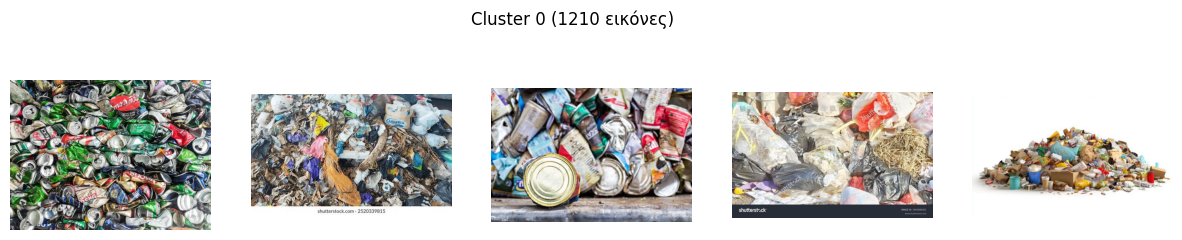

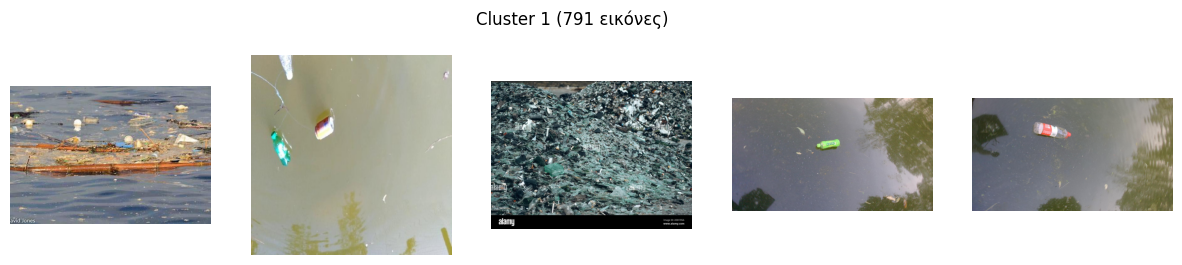

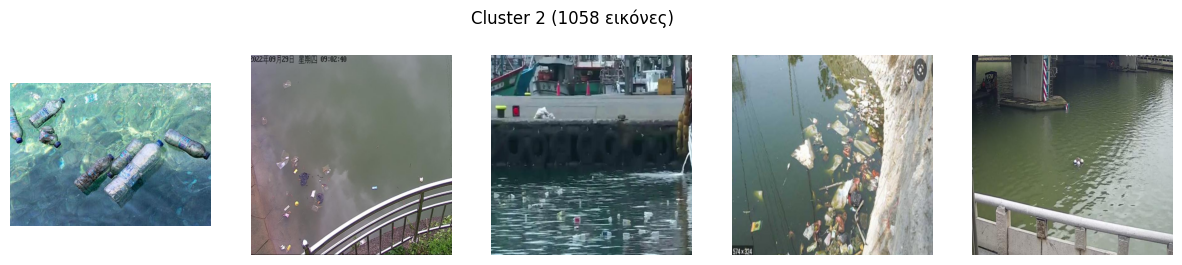

In [19]:
import matplotlib.pyplot as plt
from PIL import Image

# Δες 5 εικόνες από κάθε cluster
for cluster_id in [0, 1, 2]:
    idxs = [i for i, c in enumerate(clusters) if c == cluster_id][:5]
    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle(f"Cluster {cluster_id} ({len([c for c in clusters if c == cluster_id])} εικόνες)")
    for ax, idx in zip(axes, idxs):
        img = Image.open(image_paths[idx])
        ax.imshow(img)
        ax.axis('off')
    plt.show()